# **CAISO Market Intelligence & Curtailment Analytics Pipeline**

## SUMMARY

Developed an end-to-end Python pipeline to monitor grid health and pricing dynamics within the CAISO market. By automating data extraction from CAISO OASIS, the project analyzes Locational Marginal Prices (LMP) and renewable curtailment trends to identify regional oversupply and transmission bottlenecks. Built localized trend models for ZP26, NP15, and SP15 hubs to visualize price divergence and basis risk

- Miniconda version 26.1.1
- Python version 3.11.15
- Pandas v2.3.3
- Numpy v2.2.5
- gridstatus v0.35.0

In [15]:
import pandas as pd
from pathlib import Path
import gridstatus
import plotly.express as px
import kaleido

In [16]:
print(pd.__version__)
print(gridstatus.__version__)

2.3.3
0.35.0


## MAIN ANALYSIS

In [17]:
iso = gridstatus.CAISO()
# autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Local Marginal Price for Main Trading Hubs

- https://oasis.caiso.com/mrioasis/logon.do
- https://bpmcm.caiso.com/BPM%20Document%20Library/Market%20Instruments/BPM_for_Market%20Instruments_V92_Redline.pdf
Report definition:
- Aggregated Pricing Nodes (APND)
- Trading hub codes: NP15 (North of Path 15), ZP26 (Zone Path 26), SP15(South of Path 15)

## Download raw LMP data

In [18]:
start = pd.Timestamp("April 10, 2025").normalize()
end = pd.Timestamp.now().normalize()

locations = ["TH_NP15_GEN-APND", "TH_SP15_GEN-APND", "TH_ZP26_GEN-APND"]

lmp_df = iso.get_lmp(
    start=start, 
    end=end, 
    market="DAY_AHEAD_HOURLY", 
    locations=locations, 
    sleep=5 # rate limit 5 second for each call, prevent block
)

  0%|          | 0/12 [00:00<?, ?it/s]2026-04-15 12:34:23 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-04-15 12:34:23 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND,TH_SP15_GEN-APND,TH_ZP26_GEN-APND&startdatetime=20250410T07:00-0000&enddatetime=20250511T07:00-0000
c:\Users\delta\miniconda3\envs\grid_env_py311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'oasis.caiso.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-04-15 12:34:32 - DEBUG - Found 1 files: ['20250410_20250511_PRC_LMP_DAM_20260415_09_34_23_v12.csv']
2026-04-15 12:34:32 - DE

Error: No data found for start date: 2025-11-12 23:00:00-08:00 and end date: 2025-12-13 23:00:00-08:00
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>, 'date': Timestamp('2025-11-12 23:00:00-0800', tz='US/Pacific'), 'market': <Markets.DAY_AHEAD_HOURLY: 'DAY_AHEAD_HOURLY'>, 'locations': ['TH_NP15_GEN-APND', 'TH_SP15_GEN-APND', 'TH_ZP26_GEN-APND'], 'sleep': 5, 'end': Timestamp('2025-12-13 23:00:00-0800', tz='US/Pacific')}



c:\Users\delta\miniconda3\envs\grid_env_py311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'oasis.caiso.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-04-15 12:36:07 - WARNING - No data for 2025-12-13 23:00:00-08:00 to 2026-01-13 23:00:00-08:00
 75%|███████▌  | 9/12 [01:44<00:27,  9.23s/it]2026-04-15 12:36:07 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-04-15 12:36:07 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND,TH_SP15_GEN-APND,TH_ZP26_GEN-APND&startdatetime=20260114T07:00-0000&enddatetime=20260214T07:00-0000


Error: No data found for start date: 2025-12-13 23:00:00-08:00 and end date: 2026-01-13 23:00:00-08:00
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>, 'date': Timestamp('2025-12-13 23:00:00-0800', tz='US/Pacific'), 'market': <Markets.DAY_AHEAD_HOURLY: 'DAY_AHEAD_HOURLY'>, 'locations': ['TH_NP15_GEN-APND', 'TH_SP15_GEN-APND', 'TH_ZP26_GEN-APND'], 'sleep': 5, 'end': Timestamp('2026-01-13 23:00:00-0800', tz='US/Pacific')}



c:\Users\delta\miniconda3\envs\grid_env_py311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'oasis.caiso.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-04-15 12:36:13 - WARNING - No data for 2026-01-13 23:00:00-08:00 to 2026-02-13 23:00:00-08:00
 83%|████████▎ | 10/12 [01:49<00:16,  8.15s/it]2026-04-15 12:36:13 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-04-15 12:36:13 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND,TH_SP15_GEN-APND,TH_ZP26_GEN-APND&startdatetime=20260214T07:00-0000&enddatetime=20260317T07:00-0000


Error: No data found for start date: 2026-01-13 23:00:00-08:00 and end date: 2026-02-13 23:00:00-08:00
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>, 'date': Timestamp('2026-01-13 23:00:00-0800', tz='US/Pacific'), 'market': <Markets.DAY_AHEAD_HOURLY: 'DAY_AHEAD_HOURLY'>, 'locations': ['TH_NP15_GEN-APND', 'TH_SP15_GEN-APND', 'TH_ZP26_GEN-APND'], 'sleep': 5, 'end': Timestamp('2026-02-13 23:00:00-0800', tz='US/Pacific')}



c:\Users\delta\miniconda3\envs\grid_env_py311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'oasis.caiso.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-04-15 12:36:20 - DEBUG - Found 1 files: ['20260213_20260317_PRC_LMP_DAM_20260415_09_36_13_v12.csv']
2026-04-15 12:36:20 - DEBUG - Parsing file: 20260213_20260317_PRC_LMP_DAM_20260415_09_36_13_v12.csv
 92%|█████████▏| 11/12 [02:02<00:09,  9.55s/it]2026-04-15 12:36:26 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-04-15 12:36:26 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND,TH_SP15_GEN-APN

Errors that occurred while getting data:
[{'date': Timestamp('2025-11-12 23:00:00-0800', tz='US/Pacific'),
  'end': Timestamp('2025-12-13 23:00:00-0800', tz='US/Pacific'),
  'locations': ['TH_NP15_GEN-APND', 'TH_SP15_GEN-APND', 'TH_ZP26_GEN-APND'],
  'market': <Markets.DAY_AHEAD_HOURLY: 'DAY_AHEAD_HOURLY'>,
  'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>,
  'sleep': 5},
 {'date': Timestamp('2025-12-13 23:00:00-0800', tz='US/Pacific'),
  'end': Timestamp('2026-01-13 23:00:00-0800', tz='US/Pacific'),
  'locations': ['TH_NP15_GEN-APND', 'TH_SP15_GEN-APND', 'TH_ZP26_GEN-APND'],
  'market': <Markets.DAY_AHEAD_HOURLY: 'DAY_AHEAD_HOURLY'>,
  'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>,
  'sleep': 5},
 {'date': Timestamp('2026-01-13 23:00:00-0800', tz='US/Pacific'),
  'end': Timestamp('2026-02-13 23:00:00-0800', tz='US/Pacific'),
  'locations': ['TH_NP15_GEN-APND', 'TH_SP15_GEN-APND', 'TH_ZP26_GEN-APND'],
  'market': <Markets.DAY_AHEAD_HOURLY: 'DAY

In [43]:
# Save output of LMP for easy acess and PowerBI
output_dir = Path("raw/lpm_data/")
output_file = output_dir / "lmp_raw.csv"

output_dir.mkdir(parents=True, exist_ok=True)

lmp_df.to_csv(output_file, index = False)
print(f"File saved as: {output_dir}")

File saved as: raw\lpm_data


In [44]:
lmp_df.head()

,Time,Interval Start,Interval End,Market,Location,Location Type,LMP,Energy,Congestion,Loss
0,2025-04-10 00:00:00-07:00,2025-04-10 00:00:00-07:00,2025-04-10 01:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,36.89833,43.17463,-3.94919,-2.32711
1,2025-04-10 00:00:00-07:00,2025-04-10 00:00:00-07:00,2025-04-10 01:00:00-07:00,DAY_AHEAD_HOURLY,TH_SP15_GEN-APND,Trading Hub,43.32351,43.17463,0.94330,-0.79441
2,2025-04-10 00:00:00-07:00,2025-04-10 00:00:00-07:00,2025-04-10 01:00:00-07:00,DAY_AHEAD_HOURLY,TH_ZP26_GEN-APND,Trading Hub,39.86061,43.17463,-1.48774,-1.82629
3,2025-04-10 01:00:00-07:00,2025-04-10 01:00:00-07:00,2025-04-10 02:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,36.23791,42.53287,-4.05347,-2.24148
4,2025-04-10 01:00:00-07:00,2025-04-10 01:00:00-07:00,2025-04-10 02:00:00-07:00,DAY_AHEAD_HOURLY,TH_SP15_GEN-APND,Trading Hub,42.74047,42.53287,0.95193,-0.74433


## Figure 1: Negative Instances of Negative Locational Marginal Pricing per Month

Observed a higher negative LMP in the Spring months, where high electric runoff and solar output align with low cooling or heating demand.

In [45]:
lmp_raw = pd.read_csv(output_file, sep = ",")
# Change time columns format:
time_col = ["Time", "Interval Start", "Interval End"]
for col in time_col:
    lmp_raw[col] = pd.to_datetime(lmp_raw[col], utc=True)
    lmp_raw[col] = lmp_raw[col].dt.tz_convert("US/Pacific")

lmp_raw.head()

,Time,Interval Start,Interval End,Market,Location,Location Type,LMP,Energy,Congestion,Loss
0,2025-04-10 00:00:00-07:00,2025-04-10 00:00:00-07:00,2025-04-10 01:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,36.89833,43.17463,-3.94919,-2.32711
1,2025-04-10 00:00:00-07:00,2025-04-10 00:00:00-07:00,2025-04-10 01:00:00-07:00,DAY_AHEAD_HOURLY,TH_SP15_GEN-APND,Trading Hub,43.32351,43.17463,0.94330,-0.79441
2,2025-04-10 00:00:00-07:00,2025-04-10 00:00:00-07:00,2025-04-10 01:00:00-07:00,DAY_AHEAD_HOURLY,TH_ZP26_GEN-APND,Trading Hub,39.86061,43.17463,-1.48774,-1.82629
3,2025-04-10 01:00:00-07:00,2025-04-10 01:00:00-07:00,2025-04-10 02:00:00-07:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,36.23791,42.53287,-4.05347,-2.24148
4,2025-04-10 01:00:00-07:00,2025-04-10 01:00:00-07:00,2025-04-10 02:00:00-07:00,DAY_AHEAD_HOURLY,TH_SP15_GEN-APND,Trading Hub,42.74047,42.53287,0.95193,-0.74433


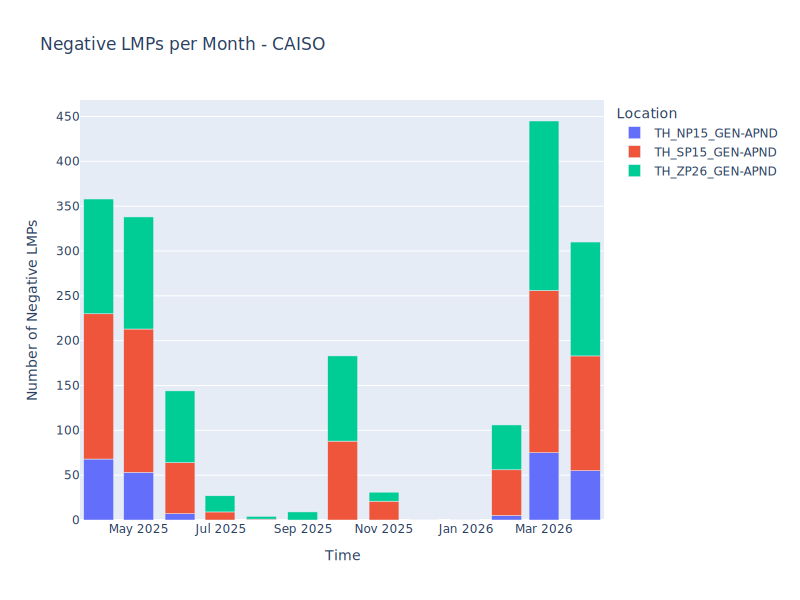

In [47]:
# Filter all negative locational merginal pricing
negative_lmps = lmp_raw[lmp_raw["LMP"] < 0].copy().set_index("Time")

# Filter negative LPM by month by location
negative_per_month = (
    negative_lmps.groupby("Location").resample("MS")["LMP"].count().reset_index()
)

# Visualization
fig = px.bar(
    negative_per_month,
    x="Time",
    y="LMP",
    title="Negative LMPs per Month - CAISO",
    color="Location",
)
fig.update_yaxes(title="Number of Negative LMPs")
fig.show("svg", width=800, height=600)

## Figure 2: Daily Average Locational Marginal Pricing (LMP) 

We observed an tight cluster regional LMP, indicate a unconstrained movement of electricity across the North, Central, and South of California

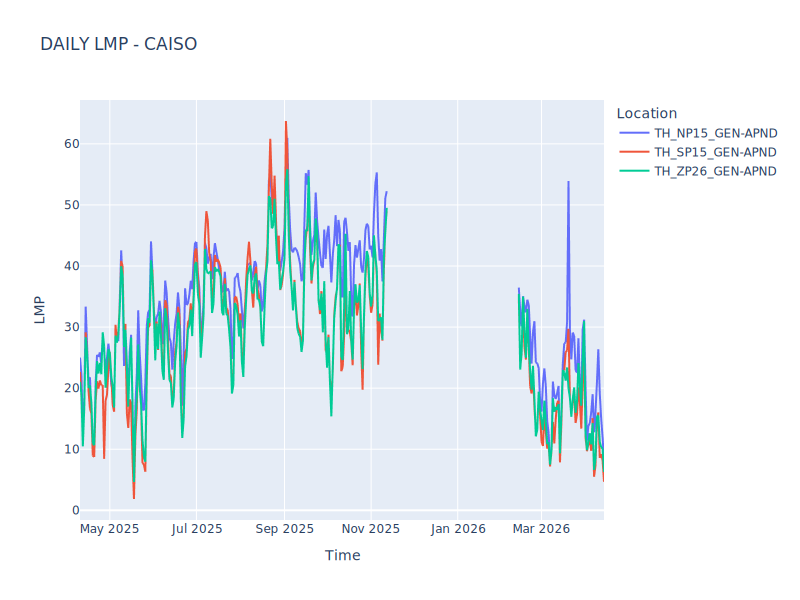

In [48]:
# Mean of daily LMP:
daily_lmp = lmp_raw.set_index("Time").groupby("Location").resample("1D")["LMP"].mean().reset_index()
fig = px.line(
    daily_lmp, 
    x="Time", 
    y="LMP", 
    title="DAILY LMP - CAISO", 
    color="Location"
)
fig.show("svg",width=800, height=600)

There was a huge missing data from the CAISO during the November 2025 and Febuary 2026 time frame. We can request access and assistant from the IT team or CAISO spoke-person.

In [49]:
daily_lmp.loc[daily_lmp["LMP"].isna()]

,Location,Time,LMP
217,TH_NP15_GEN-APND,2025-11-13 00:00:00-08:00,NaN
218,TH_NP15_GEN-APND,2025-11-14 00:00:00-08:00,NaN
219,TH_NP15_GEN-APND,2025-11-15 00:00:00-08:00,NaN
220,TH_NP15_GEN-APND,2025-11-16 00:00:00-08:00,NaN
221,TH_NP15_GEN-APND,2025-11-17 00:00:00-08:00,NaN
...,...,...,...
1044,TH_ZP26_GEN-APND,2026-02-08 00:00:00-08:00,NaN
1045,TH_ZP26_GEN-APND,2026-02-09 00:00:00-08:00,NaN
1046,TH_ZP26_GEN-APND,2026-02-10 00:00:00-08:00,NaN
1047,TH_ZP26_GEN-APND,2026-02-11 00:00:00-08:00,NaN


# Energy Curtailment

## Download raw curtailmant data

- Company can purposefully reduce output of renewable energy (wind, solar). Here, we can investigate the curtailment status

In [50]:
curtail_df = iso.get_curtailment(
    start="April 10, 2025", 
    end="today", 
    # save_to="curtailment/"
)

  0%|          | 1/371 [00:00<05:51,  1.05it/s]

Error: Failed to fetch renewables report for 2025-04-10: HTTP 404
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>, 'date': Timestamp('2025-04-10 00:00:00-0700', tz='US/Pacific')}



  1%|          | 2/371 [00:01<05:07,  1.20it/s]

Error: Failed to fetch renewables report for 2025-04-11: HTTP 404
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>, 'date': Timestamp('2025-04-11 00:00:00-0700', tz='US/Pacific')}



  1%|          | 3/371 [00:02<04:40,  1.31it/s]

...

Error: Renewables report column curt_monthly_ytd_perc_mwh returned 12 values for 2026-01-31, expected 13
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>, 'date': Timestamp('2026-01-31 00:00:00-0800', tz='US/Pacific')}



100%|█████████▉| 370/371 [03:00<00:00,  1.65it/s]

Error: Failed to fetch renewables report for 2026-04-14: HTTP 404
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>, 'date': Timestamp('2026-04-14 00:00:00-0700', tz='US/Pacific')}



100%|██████████| 371/371 [03:01<00:00,  2.05it/s]

Error: Failed to fetch renewables report for 2026-04-15: HTTP 404
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>, 'date': Timestamp('2026-04-15 00:00:00-0700', tz='US/Pacific')}

Errors that occurred while getting data:
[{'date': Timestamp('2025-04-10 00:00:00-0700', tz='US/Pacific'),
  'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>},
 {'date': Timestamp('2025-04-11 00:00:00-0700', tz='US/Pacific'),
  'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>},
 {'date': Timestamp('2025-04-12 00:00:00-0700', tz='US/Pacific'),
  'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>},
 {'date': Timestamp('2025-04-13 00:00:00-0700', tz='US/Pacific'),
  'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>},
 {'date': Timestamp('2025-04-14 00:00:00-0700', tz='US/Pacific'),
  'self': <gridstatus.caiso.caiso.CAISO object at 0x0000021D07D72790>},
 {'date': Timestamp('2025-04-15 00:00:00-0700', tz='US/Pacific

In [51]:
# Save output of curtailment data for easy acess and PowerBI
output_dir = Path("raw/curtailment_data/")
output_file = output_dir / "curl_raw.csv"

output_dir.mkdir(parents=True, exist_ok=True)

curtail_df.to_csv(output_file)
print(f"File saved as: {output_dir}")

File saved as: raw\curtailment_data


In [52]:
curtail_df.head()

,Interval Start,Interval End,Curtailment Type,Curtailment Reason,Fuel Type,Curtailment MWH,Curtailment MW
0,2025-06-01 00:00:00-07:00,2025-06-01 01:00:00-07:00,Economic,Local,Solar,0.000000,0.0
1,2025-06-01 00:00:00-07:00,2025-06-01 01:00:00-07:00,Economic,Local,Wind,0.000045,0.0
2,2025-06-01 00:00:00-07:00,2025-06-01 01:00:00-07:00,Economic,System,Solar,0.000000,0.0
3,2025-06-01 00:00:00-07:00,2025-06-01 01:00:00-07:00,Economic,System,Wind,0.000066,0.0
4,2025-06-01 00:00:00-07:00,2025-06-01 01:00:00-07:00,OperatorInstruction,Local,Solar,0.000000,0.0


In [54]:
# Open from local raw:
curl_raw = pd.read_csv(output_file)
# Change time columns format:
time_col = ["Interval Start", "Interval End"]
for col in time_col:
    curl_raw[col] = pd.to_datetime(curl_raw[col], utc=True)
    curl_raw[col] = curl_raw[col].dt.tz_convert("US/Pacific")

# Adjust format
curl_raw.columns = curl_raw.columns.str.strip()

curl_raw["Type"] = (
    curl_raw["Curtailment Reason"].str.lower().str.capitalize()
    + " "
    + curl_raw["Fuel Type"]
    + " Curtailment (MWh)"
)
curtailment = curl_raw.pivot_table(
    values="Curtailment MWH",
    index="Interval Start",
    columns="Type",
    # sum to account for 'Economic' and 'SelfSchCut' reasons
    aggfunc="sum",
).fillna(0)

curtailment["Total Solar Curtailment (MWh)"] = (
    curtailment["Local Solar Curtailment (MWh)"]
    + curtailment["System Solar Curtailment (MWh)"]
)
curtailment["Total Wind Curtailment (MWh)"] = (
    curtailment["Local Wind Curtailment (MWh)"]
    + curtailment["System Wind Curtailment (MWh)"]
)
curtailment["Total Curtailment (MWh)"] = (
    curtailment["Total Solar Curtailment (MWh)"]
    + curtailment["Total Wind Curtailment (MWh)"]
)
curtailment.columns.name = None
curtailment = curtailment.resample("1h").sum()

curtailment.head()

,Local Solar Curtailment (MWh),Local Wind Curtailment (MWh),System Solar Curtailment (MWh),System Wind Curtailment (MWh),Total Solar Curtailment (MWh),Total Wind Curtailment (MWh),Total Curtailment (MWh)
Interval Start,,,,,,,
2025-06-01 00:00:00-07:00,0.0,0.000045,0.0,0.000066,0.0,0.000111,0.000111
2025-06-01 01:00:00-07:00,0.0,0.000010,0.0,0.000104,0.0,0.000114,0.000114
2025-06-01 02:00:00-07:00,0.0,0.000047,0.0,0.000063,0.0,0.000110,0.000110
2025-06-01 03:00:00-07:00,0.0,0.000023,0.0,0.000080,0.0,0.000104,0.000104
2025-06-01 04:00:00-07:00,0.0,0.000073,0.0,0.000024,0.0,0.000097,0.000097


## Figure 3: Cumalative Curtailment in 2025 and 2026

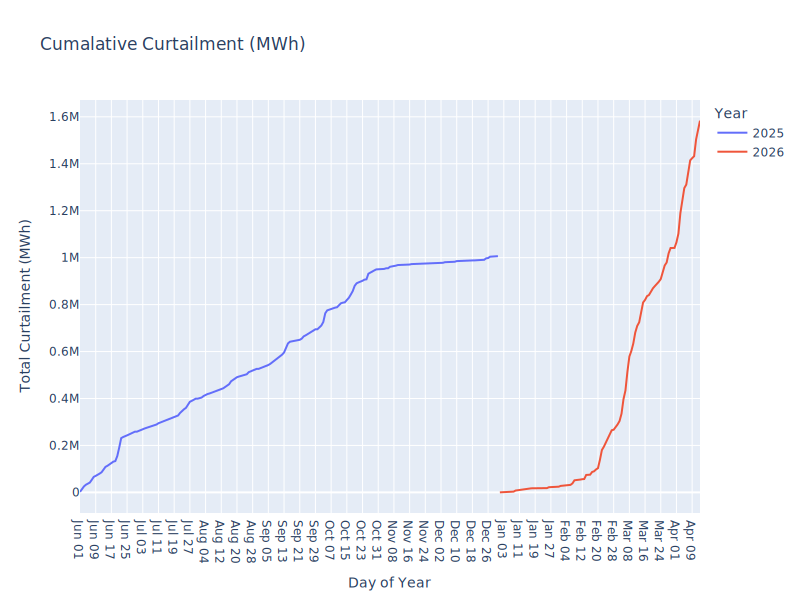

In [55]:
# Create sum table
daily_curtailment = curtailment.resample("1D").sum()
cumulative_curtailment = (
    daily_curtailment.groupby(daily_curtailment.index.year)["Total Curtailment (MWh)"]
    .cumsum()
    .reset_index()
)

# add year and month 
cumulative_curtailment["Year"] = cumulative_curtailment["Interval Start"].dt.year
cumulative_curtailment["Day of Year"] = cumulative_curtailment[
    "Interval Start"
].dt.strftime("%b %d")

# plot all years together
fig = px.line(
    cumulative_curtailment,
    y="Total Curtailment (MWh)",
    x="Day of Year",
    title="Cumalative Curtailment (MWh)",
    color="Year",
)

fig.show("svg", width=800, height=600)

## Figure 4: Monthly Curtailment

We observed a high curtailment during the Spring time, this is consistent with reduction in demand of heating or cooling use during the Spring time.

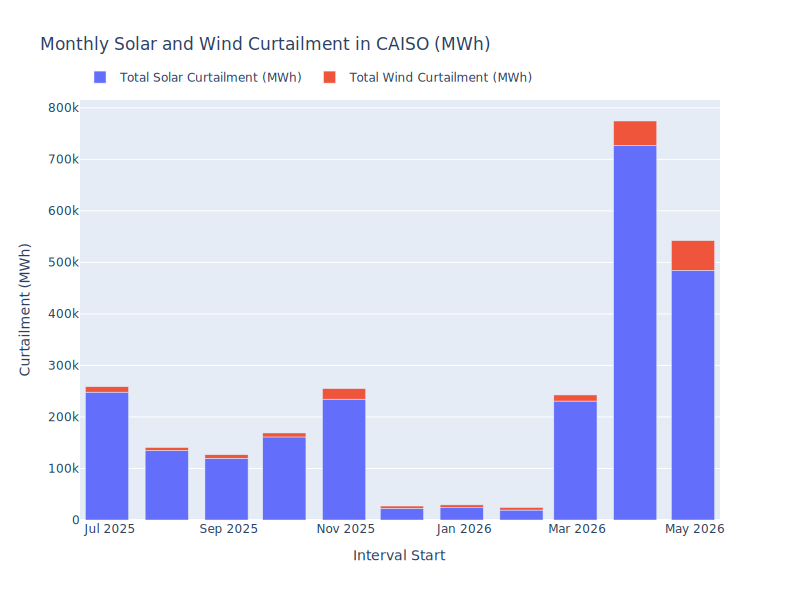

In [56]:
monthly = curtailment.resample("ME").sum()
monthly["Month"] = monthly.index.month
monthly["Year"] = monthly.index.year

# plot
fig = px.bar(
    monthly,
    x=monthly.index,
    y=["Total Solar Curtailment (MWh)", "Total Wind Curtailment (MWh)"],
    title="Monthly Solar and Wind Curtailment in CAISO (MWh)",
)

# legend upper left corner
fig.update_layout(
    legend=dict(
        orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0, title_text=None
    )
)
fig.update_yaxes(title_text="Curtailment (MWh)")
fig.show("svg", width=800, height=600)

# List all data set for download

In [ ]:
iso.list_oasis_datasets()

Dataset: transmission_interface_usage
+---------------+-----------+-------------------+
| Parameter     | Default   | Possible Values   |
+===============+===========+===================+
| market_run_id | DAM       | DAM, HASP, RRPD   |
+---------------+-----------+-------------------+
| ti_id         | ALL       | N/A               |
+---------------+-----------+-------------------+
| ti_direction  | ALL       | ALL, E, I         |
+---------------+-----------+-------------------+


Dataset: schedule_by_tie
+-------------+------------------------+-------------------------------------------------------------------------------------------------+
| Parameter   | Default                | Possible Values                                                                                 |
+=============+========================+=================================================================================================+
| groupid     | RTD_ENE_SCH_BY_TIE_GRP | RTD_ENE_SCH_BY_TIE_GRP, DAM

In [ ]:
iso.list_oasis_datasets("lmp_day_ahead_hourly")

Dataset: lmp_day_ahead_hourly
+---------------+-----------+------------------------+
| Parameter     | Default   | Possible Values        |
+===============+===========+========================+
| market_run_id | DAM       | N/A                    |
+---------------+-----------+------------------------+
| node          |           | N/A                    |
+---------------+-----------+------------------------+
| grp_type      |           | None, ALL, ALL_APNODES |
+---------------+-----------+------------------------+




In [ ]:
df = iso.get_oasis_dataset(
    dataset="lmp_day_ahead_hourly",
    params={
        "market_run_id": "DAM",
    },
    date="April 10, 2026",
)
df.head()

2026-04-14 21:27:05 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-04-14 21:27:05 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&startdatetime=20260410T07:00-0000&enddatetime=20260411T07:00-0000
c:\Users\delta\miniconda3\envs\grid_env_py311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'oasis.caiso.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\delta\miniconda3\envs\grid_env_py311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'oasis.caiso.com'. Adding certificate verification is st

,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,OPR_DT,OPR_HR,OPR_INTERVAL,NODE_ID_XML,NODE_ID,NODE,MARKET_RUN_ID,LMP_TYPE,XML_DATA_ITEM,PNODE_RESMRID,GRP_TYPE,POS,MW,GROUP
163184,2026-04-10 07:00:00+00:00,2026-04-10 08:00:00+00:00,2026-04-10,1,0,HYML_LNODEYML,HYML_LNODEYML,HYML_LNODEYML,DAM,LMP,LMP_PRC,HYML_LNODEYML,ALL,1,32.98967,6800
157306,2026-04-10 07:00:00+00:00,2026-04-10 08:00:00+00:00,2026-04-10,1,0,HOL_1_HAFBS1_SLRGNODE,HOL_1_HAFBS1_SLRGNODE,HOL_1_HAFBS1_SLRGNODE,DAM,MGHG,LMP_GHG_PRC,HOL_1_HAFBS1_SLRGNODE,ALL,1,0.00000,6555
194839,2026-04-10 07:00:00+00:00,2026-04-10 08:00:00+00:00,2026-04-10,1,0,LONETREE_2_N014,LONETREE_2_N014,LONETREE_2_N014,DAM,MCC,LMP_CONG_PRC,LONETREE_2_N014,ALL,1,0.00000,8119
49362,2026-04-10 07:00:00+00:00,2026-04-10 08:00:00+00:00,2026-04-10,1,0,CASHI_SR_LNODELD5,CASHI_SR_LNODELD5,CASHI_SR_LNODELD5,DAM,MCE,LMP_ENE_PRC,CASHI_SR_LNODELD5,ALL,1,34.42520,2057
194878,2026-04-10 07:00:00+00:00,2026-04-10 08:00:00+00:00,2026-04-10,1,0,LONE_MTN_LNODEK1L,LONE_MTN_LNODEK1L,LONE_MTN_LNODEK1L,DAM,MCC,LMP_CONG_PRC,LONE_MTN_LNODEK1L,ALL,1,0.00000,8120


# -- End